Loading training data...
Preprocessing training data...
Loading test data...
Aligning columns...
Preprocessing test data...
Splitting data for validation...
Training XGBoost model...

Generating validation predictions...


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [21:26:51] WARNING: /workspace/src/common/error_msg.cc:41: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



Validation AUC: 0.9687


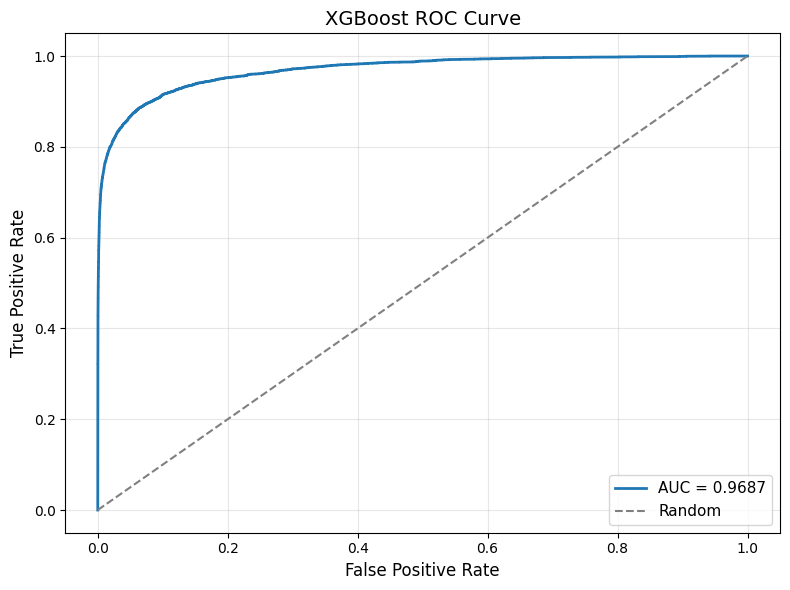


Confusion Matrix (threshold=0.5):
[[110854   3121]
 [   727   3406]]

True Negatives:  110854
False Positives: 3121
False Negatives: 727
True Positives:  3406

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    113975
           1       0.52      0.82      0.64      4133

    accuracy                           0.97    118108
   macro avg       0.76      0.90      0.81    118108
weighted avg       0.98      0.97      0.97    118108



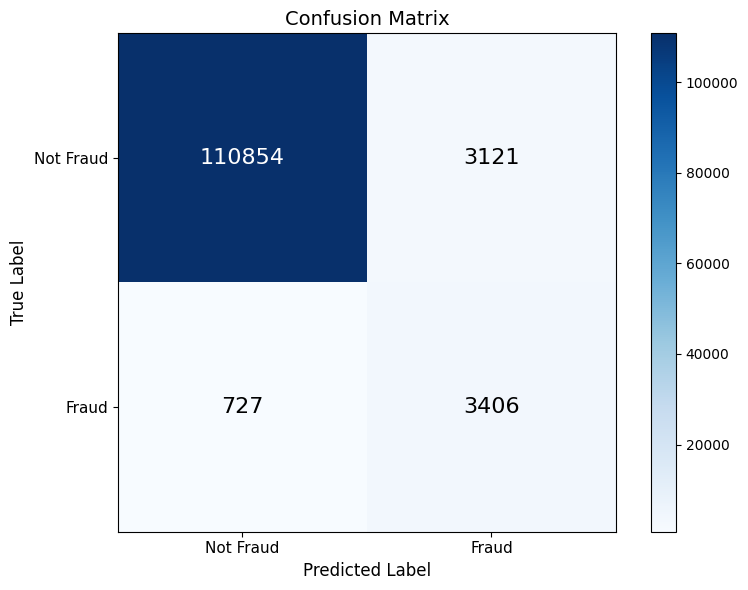


Training final model on full dataset for submission...

Making predictions on test data...

Submission file created successfully!
Predictions range: [0.0000, 0.9999]
Mean prediction: 0.1095
Fraud rate in predictions: 0.0475

First few predictions:
   TransactionID   isFraud
0        3663549  0.003831
1        3663550  0.007089
2        3663551  0.003333
3        3663552  0.014529
4        3663553  0.002260
5        3663554  0.025998
6        3663555  0.025434
7        3663556  0.104469
8        3663557  0.000230
9        3663558  0.122136


In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
import xgboost as xgb

# Load training data
print("Loading training data...")
train_transaction = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_identity.csv')

train_data = train_transaction.merge(train_identity, how='left', on='TransactionID')

y = train_data['isFraud']
X = train_data.drop(['isFraud', 'TransactionID'], axis=1)

# Identify column types
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

# Preprocess training data
print("Preprocessing training data...")
X[cat_cols] = X[cat_cols].fillna('missing')

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = enc.fit_transform(X[cat_cols])

# Store median values for test imputation
num_medians = X[num_cols].median()

X[num_cols] = X[num_cols].fillna(num_medians)
X[num_cols] = X[num_cols].astype('float32')

# Load test data
print("Loading test data...")
test_transaction = pd.read_csv('/kaggle/input/ieee-fraud-detection/test_transaction.csv')
test_identity = pd.read_csv('/kaggle/input/ieee-fraud-detection/test_identity.csv')

test_data = test_transaction.merge(test_identity, how='left', on='TransactionID')
test_ids = test_data['TransactionID']
X_test = test_data.drop(['TransactionID'], axis=1)

# Align test columns with training columns
print("Aligning columns...")
# Add missing columns with NaN
for col in X.columns:
    if col not in X_test.columns:
        X_test[col] = np.nan

# Remove extra columns and reorder to match training
X_test = X_test[X.columns]

# Identify which categorical and numeric columns exist in test
cat_cols_test = [col for col in cat_cols if col in X_test.columns]
num_cols_test = [col for col in num_cols if col in X_test.columns]

# Preprocess test data
print("Preprocessing test data...")
X_test[cat_cols_test] = X_test[cat_cols_test].fillna('missing')
X_test[cat_cols_test] = enc.transform(X_test[cat_cols_test])

X_test[num_cols_test] = X_test[num_cols_test].fillna(num_medians[num_cols_test])
X_test[num_cols_test] = X_test[num_cols_test].astype('float32')

# Split data for validation to generate metrics
from sklearn.model_selection import train_test_split

print("Splitting data for validation...")
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Train model on training split
print("Training XGBoost model...")
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = xgb.XGBClassifier(
    n_estimators=800,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    max_bin=256,
    tree_method='hist',
    device='cuda',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

model.fit(X_train, y_train, verbose=100)

# Generate validation predictions for metrics
print("\nGenerating validation predictions...")
val_preds = model.predict_proba(X_val)[:, 1]

# Calculate AUC Score
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt

val_auc = roc_auc_score(y_val, val_preds)
print(f"\nValidation AUC: {val_auc:.4f}")

# Generate ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, val_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('XGBoost ROC Curve', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

# Generate Confusion Matrix
threshold = 0.5
y_pred = (val_preds >= threshold).astype(int)

cm = confusion_matrix(y_val, y_pred)
print("\nConfusion Matrix (threshold=0.5):")
print(cm)
print(f"\nTrue Negatives:  {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives:  {cm[1, 1]}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix', fontsize=14)
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Not Fraud', 'Fraud'], fontsize=11)
plt.yticks(tick_marks, ['Not Fraud', 'Fraud'], fontsize=11)

# Add text annotations
for i in range(2):
    for j in range(2):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=16)

plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\n" + "="*50)
print("Training final model on full dataset for submission...")
print("="*50)

# Now train on full dataset for final predictions
scale_pos_weight_full = (y == 0).sum() / (y == 1).sum()

final_model = xgb.XGBClassifier(
    n_estimators=800,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    max_bin=256,
    tree_method='hist',
    device='cuda',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight_full,
    random_state=42
)

final_model.fit(X, y, verbose=100)

# Make predictions on test data
print("\nMaking predictions on test data...")
test_preds = final_model.predict_proba(X_test)[:, 1]

# Create submission file
submission = pd.DataFrame({
    'TransactionID': test_ids,
    'isFraud': test_preds
})

submission.to_csv('submission.csv', index=False)
print("\nSubmission file created successfully!")
print(f"Predictions range: [{test_preds.min():.4f}, {test_preds.max():.4f}]")
print(f"Mean prediction: {test_preds.mean():.4f}")
print(f"Fraud rate in predictions: {(test_preds > 0.5).mean():.4f}")
print("\nFirst few predictions:")
print(submission.head(10))